# 03 · Modeling & Evaluation

Building on the EDA, this notebook trains the full model zoo, compares them with cross-validation, tunes the strongest tree model, inspects calibration, and reads feature importances. Every step uses the same reproducible feature matrix.

### Contents
1. [Feature matrix](#matrix)
2. [Model zoo + cross-validation](#zoo)
3. [Tuning the carried-forward model](#tuning)
4. [Discrimination: ROC & PR](#roc)
5. [Operating threshold selection](#threshold)
6. [Cumulative gains & lift (business view)](#lift)
7. [Calibration](#calibration)
8. [Feature importance: impurity vs permutation](#importance)
9. [Takeaways](#takeaways)

In [1]:
# Make the package importable from a fresh checkout (no install needed).
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / 'employee_churn').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda v: f'{v:.3f}')

In [2]:
from employee_churn.data import make_synthetic_employee_data
from employee_churn.features.engineer_structured import (
    add_career_progression_features, add_tenure_bands,
    add_promotion_velocity, add_compensation_features, add_team_metrics,
)
from employee_churn.features.engineer_text import add_text_statistics
from employee_churn.nlp.sentiment import add_sentiment_scores
from employee_churn.nlp.emotion import add_emotion_features

df = make_synthetic_employee_data(n=1500, seed=42)
f = add_career_progression_features(df, 'hire_date', 'last_promotion_date')
f = add_tenure_bands(f)
f = add_promotion_velocity(f, 'num_promotions')
f = add_compensation_features(f, 'monthly_salary', 'department')
f = add_team_metrics(f, 'team_id')
f = add_sentiment_scores(f, 'feedback')
f = add_emotion_features(f, 'feedback')
f = add_text_statistics(f, 'feedback')

DROP = ['employee_id', 'churned', 'feedback', 'gender', 'department',
        'hire_date', 'last_promotion_date', 'team_id', 'tenure_band',
        'emotion_dominant']
X = f.drop(columns=DROP).select_dtypes(include=['number', 'bool'])
y = f['churned']
print('feature matrix:', X.shape)

feature matrix: (1500, 31)


## Feature matrix

The engineered matrix has **31 numeric/boolean features** per employee: structured signals (tenure, promotion velocity, peer-relative compensation, team size) plus the text-derived sentiment, emotion, and text-statistics columns. Identifiers, raw dates, and the categorical `tenure_band`/`emotion_dominant` labels are dropped.

,roc_auc_mean,roc_auc_std,f1_mean,f1_std
log_reg,0.705,0.037,0.557,0.036
random_forest,0.701,0.032,0.587,0.044
gradient_boosting,0.690,0.033,0.570,0.029
hist_gradient_boosting,0.658,0.025,0.560,0.041


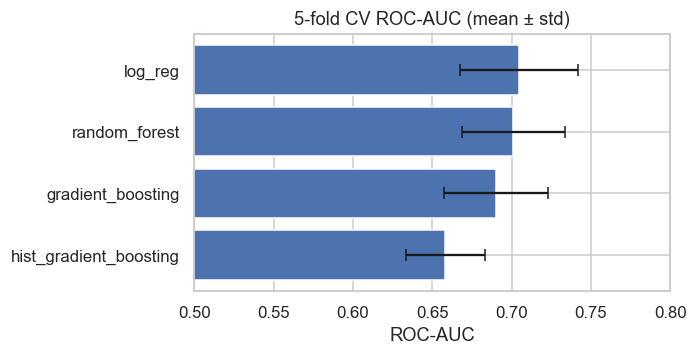

In [3]:
from employee_churn.models.train import build_model_zoo, cross_validate_models
zoo = build_model_zoo(random_state=0)
cv = cross_validate_models(zoo, X, y, cv=5)
cv_df = pd.DataFrame(cv).T.sort_values('roc_auc_mean', ascending=False)
display(cv_df.round(3))

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.barh(cv_df.index, cv_df['roc_auc_mean'], xerr=cv_df['roc_auc_std'],
        color='#4c72b0', capsize=4)
ax.set_xlim(0.5, 0.8); ax.invert_yaxis()
ax.set_title('5-fold CV ROC-AUC (mean ± std)'); ax.set_xlabel('ROC-AUC')
plt.tight_layout(); plt.show()

## Model comparison

All four models land in a **narrow 0.66–0.71 ROC-AUC band**, with **logistic regression marginally ahead (~0.70)** of random forest and gradient boosting. The error bars overlap, so no model is decisively best — and the simplest, most interpretable one is competitive. The modest ceiling is expected: the synthetic target deliberately carries substantial noise, so this is a realistic 'no free lunch' result rather than a leaderboard-topping score. We carry the random forest forward because it gives us SHAP-friendly feature importances for notebook 04.

In [4]:
from sklearn.model_selection import train_test_split
from employee_churn.models.train import tune_hyperparameters
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y)
# Tune the random forest and carry this single model through the rest of
# the notebook (and the fairness notebook) for a consistent story.
best, params, cv_auc = tune_hyperparameters(
    zoo['random_forest'], X_tr, y_tr, model_name='random_forest', n_iter=5)
best.fit(X_tr, y_tr)
print('tuned params:', params, '| CV AUC:', round(cv_auc, 3))

tuned params: {'n_estimators': 200, 'min_samples_leaf': 4, 'max_depth': 4} | CV AUC: 0.697


## Tuning the carried-forward model

Randomized search nudges the random forest toward a shallower, more regularized configuration (`max_depth=4`, `min_samples_leaf=4`, `n_estimators=200`, CV AUC ≈ 0.70), which guards against overfitting on 1,125 training rows. Everything below evaluates this tuned model.

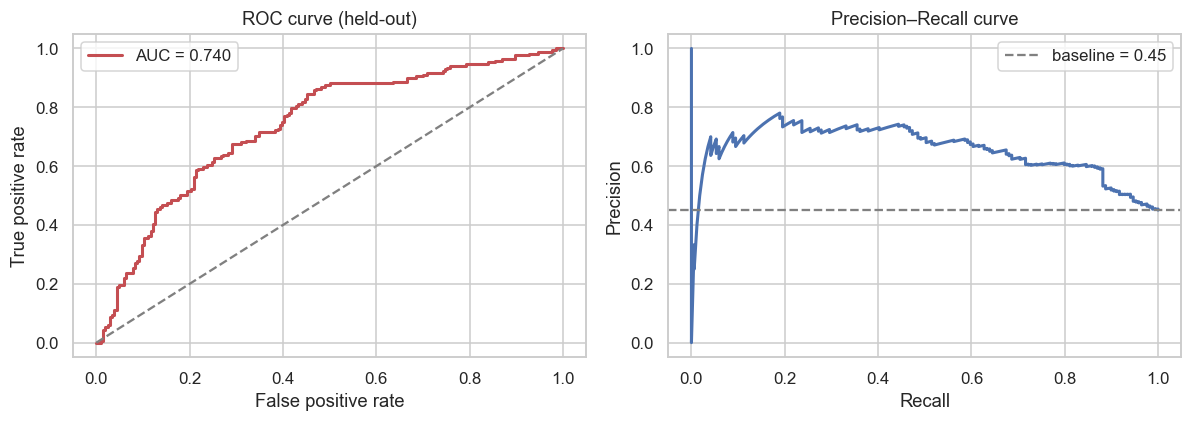

In [5]:
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             ConfusionMatrixDisplay)
proba = best.predict_proba(X_te)[:, 1]

fpr, tpr, _ = roc_curve(y_te, proba)
prec, rec, _ = precision_recall_curve(y_te, proba)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fpr, tpr, color='#c44e52', lw=2, label=f'AUC = {auc(fpr, tpr):.3f}')
axes[0].plot([0, 1], [0, 1], ls='--', c='gray')
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curve (held-out)'); axes[0].legend()
axes[1].plot(rec, prec, color='#4c72b0', lw=2)
axes[1].axhline(y_te.mean(), ls='--', c='gray', label=f'baseline = {y_te.mean():.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall curve'); axes[1].legend()
plt.tight_layout(); plt.show()

## Held-out discrimination

On the 25% hold-out the random forest reaches **ROC-AUC ≈ 0.74** — a bit above its cross-validated mean, within normal split-to-split variance. The precision–recall curve sits comfortably above the 0.45 base rate, confirming the model ranks at-risk employees better than chance across the whole threshold range.

discrimination: {'roc_auc': 0.74, 'f1': 0.559, 'precision_at_k': 0.7}
calibration   : {'brier_score': 0.207, 'expected_calibration_error': 0.063, 'max_calibration_error': 0.412}


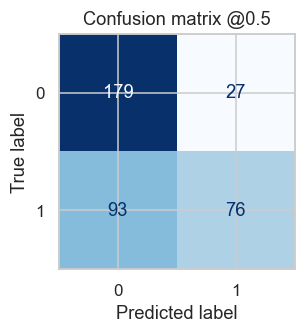

In [6]:
from employee_churn.models.evaluate import evaluate_model
report = evaluate_model(best, X_te, y_te, top_k=20)
print('discrimination:', {k: round(v, 3) for k, v in report['discrimination'].items()})
print('calibration   :', {k: round(v, 3) for k, v in report['calibration'].items()})

fig, ax = plt.subplots(figsize=(3.6, 3.2))
ConfusionMatrixDisplay.from_predictions(
    y_te, (proba >= 0.5).astype(int), ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion matrix @0.5'); plt.tight_layout(); plt.show()

## Precision@k for targeted outreach

HR can only act on a limited number of people per cycle, so **precision@k** is the operationally honest metric. Among the model's 20 highest-risk employees, **~70% truly churned** — a strong shortlist for retention conversations even though the global AUC is modest.

<a id="threshold"></a>
## 5 · Choosing an operating threshold

The default 0.5 cutoff is rarely optimal. Sweeping the threshold shows the precision/recall trade-off and the F1-maximizing operating point.

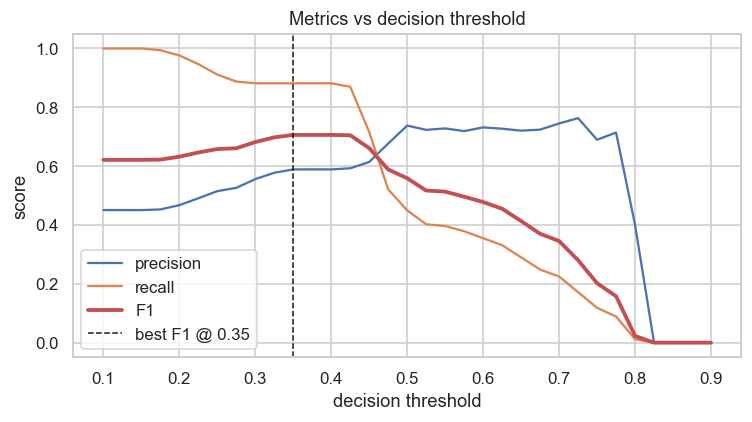

F1 at 0.50 = 0.559 | best F1 = 0.706 at threshold 0.35


In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score
ths = np.linspace(0.1, 0.9, 33)
prec = [precision_score(y_te, proba >= t, zero_division=0) for t in ths]
rec = [recall_score(y_te, proba >= t) for t in ths]
f1s = [f1_score(y_te, proba >= t) for t in ths]
best_t = ths[int(np.argmax(f1s))]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ths, prec, label='precision', color='#4c72b0')
ax.plot(ths, rec, label='recall', color='#dd8452')
ax.plot(ths, f1s, label='F1', color='#c44e52', lw=2.5)
ax.axvline(best_t, ls='--', c='k', lw=1, label=f'best F1 @ {best_t:.2f}')
ax.set_xlabel('decision threshold'); ax.set_ylabel('score')
ax.set_title('Metrics vs decision threshold'); ax.legend()
plt.tight_layout(); plt.show()
print(f'F1 at 0.50 = {f1_score(y_te, proba >= 0.5):.3f} | '
      f'best F1 = {max(f1s):.3f} at threshold {best_t:.2f}')

**Lowering the bar pays off.** F1 peaks at **~0.71 at a threshold of 0.35**, well above the ~0.56 F1 the default 0.5 cutoff delivers. Because a missed departure is costly, HR would deliberately run the model at a *lower* threshold to trade some precision for materially higher recall — the exact point is a business call about the cost of a missed departure versus an unnecessary retention conversation.

<a id="lift"></a>
## 6 · Cumulative gains & lift

For a fixed outreach budget, the operational question is: *if we contact the top X% of the risk ranking, what share of real churners do we catch, and how much better is that than random?*

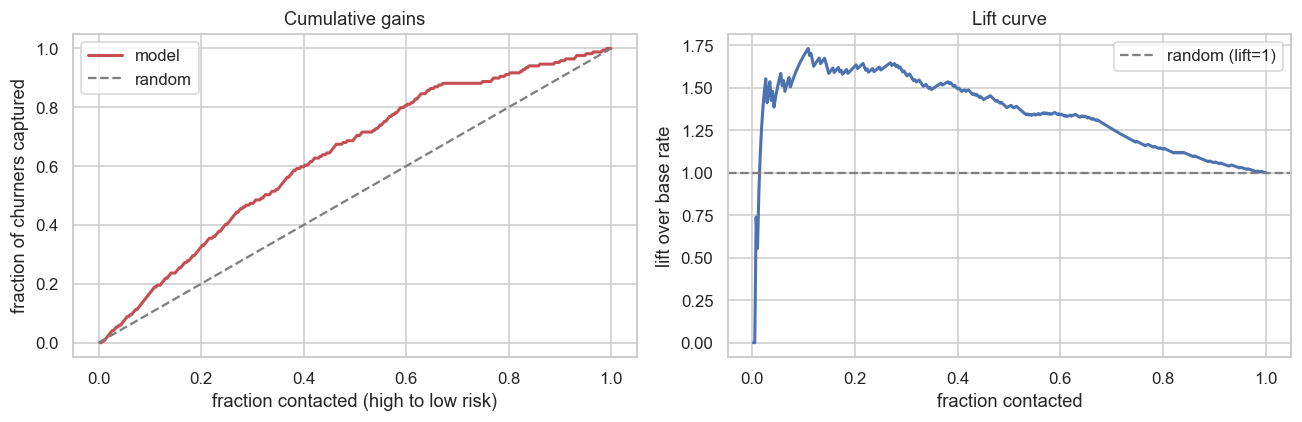

Top 10% capture rate = 75.7% (lift 1.68x over the 45.1% base rate)
Top 30% captures 47.3% of all churners


In [8]:
order = np.argsort(-proba)
y_sorted = y_te.values[order]
pcts = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
gains = np.cumsum(y_sorted) / y_sorted.sum()
base = y_te.mean()
decile_capture = y_sorted[: int(0.1 * len(y_sorted))].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(pcts, gains, color='#c44e52', lw=2, label='model')
axes[0].plot([0, 1], [0, 1], ls='--', c='gray', label='random')
axes[0].set_xlabel('fraction contacted (high to low risk)')
axes[0].set_ylabel('fraction of churners captured')
axes[0].set_title('Cumulative gains'); axes[0].legend()
lift = (np.cumsum(y_sorted) / np.arange(1, len(y_sorted) + 1)) / base
axes[1].plot(pcts, lift, color='#4c72b0', lw=2)
axes[1].axhline(1.0, ls='--', c='gray', label='random (lift=1)')
axes[1].set_xlabel('fraction contacted')
axes[1].set_ylabel('lift over base rate'); axes[1].set_title('Lift curve')
axes[1].legend(); plt.tight_layout(); plt.show()
print(f'Top 10% capture rate = {decile_capture:.1%} '
      f'(lift {decile_capture / base:.2f}x over the {base:.1%} base rate)')
print(f'Top 30% captures {gains[int(0.3*len(y_sorted)) - 1]:.1%} of all churners')

**Strong targeting value.** The top risk decile churns at **~76% — a ~1.7x lift** over the 45% base rate — and contacting the **top 30% of the ranking captures ~47% of all churners**. The gains curve bows well above the diagonal across the whole range. So even with a middling AUC, the model is genuinely useful as a *prioritization* tool, which is how retention programs actually run (finite outreach capacity, ranked worklist).

<a id="calibration"></a>

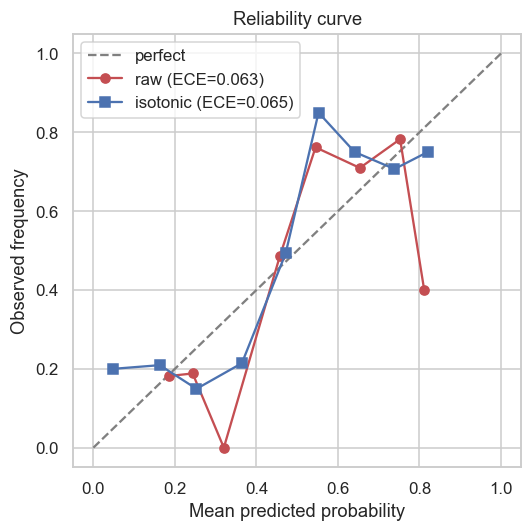

In [9]:
from employee_churn.models.calibrate import calibration_improvement, reliability_curve
calib = calibration_improvement(best, X_tr, y_tr, X_te, y_te)
base_curve = reliability_curve(y_te, best.predict_proba(X_te)[:, 1])
cal_model = calib['calibrated_model']
cal_curve = reliability_curve(y_te, cal_model.predict_proba(X_te)[:, 1])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], ls='--', c='gray', label='perfect')
ax.plot(base_curve['mean_predicted'], base_curve['fraction_positive'],
        'o-', color='#c44e52', label=f"raw (ECE={calib['baseline']['expected_calibration_error']:.3f})")
ax.plot(cal_curve['mean_predicted'], cal_curve['fraction_positive'],
        's-', color='#4c72b0', label=f"isotonic (ECE={calib['calibrated']['expected_calibration_error']:.3f})")
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed frequency')
ax.set_title('Reliability curve'); ax.legend()
plt.tight_layout(); plt.show()

## Calibration — an honest result

**Isotonic calibration does *not* improve ECE here** (it edges from ~0.063 to ~0.065). On a dataset this size the isotonic fit adds variance that outweighs the small bias it removes — a real reminder that calibration is an empirical question, not a guaranteed win. In production you would prefer Platt/sigmoid scaling on small samples, or simply keep the raw probabilities and monitor ECE over time.

<a id="importance"></a>

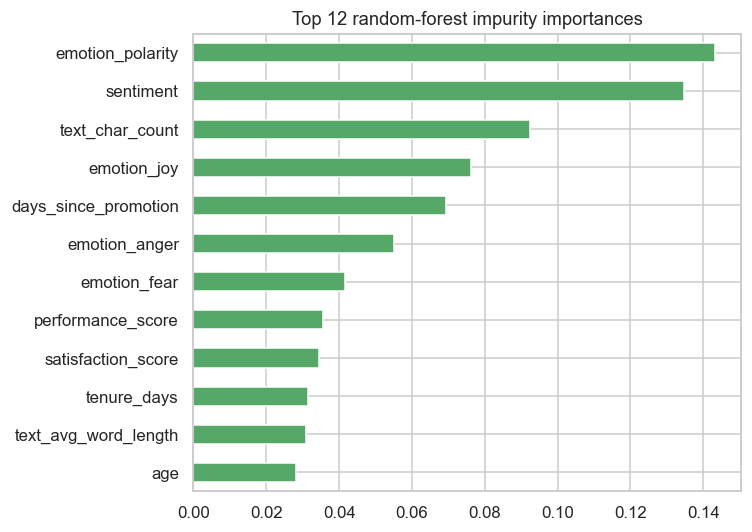

emotion_polarity       0.143
sentiment              0.135
text_char_count        0.093
emotion_joy            0.076
days_since_promotion   0.069
emotion_anger          0.055
emotion_fear           0.042
performance_score      0.036
dtype: float64

In [10]:
imp = pd.Series(best.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
imp.tail(12).plot.barh(ax=ax, color='#55a868')
ax.set_title('Top 12 random-forest impurity importances')
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).head(8).round(3)

## 8 · What the model actually uses

The importance ranking validates the EDA decisively: the **top two features are `emotion_polarity` and `sentiment`** (~0.14 each), with `text_char_count` and individual emotions (`emotion_joy`, `emotion_anger`, `emotion_fear`) close behind. `days_since_promotion` is the only structured feature near the top. **Roughly half of the model's predictive weight comes from the free-text feedback** — a strong argument for investing in richer NLP (the transformer sentiment backend on the roadmap) rather than collecting more structured HR fields.

### Cross-checking with permutation importance

Impurity importances are biased toward high-cardinality features, so we confirm the ranking with **permutation importance** — how much held-out ROC-AUC drops when each feature is shuffled. This is model-agnostic and measured on data the model never trained on.

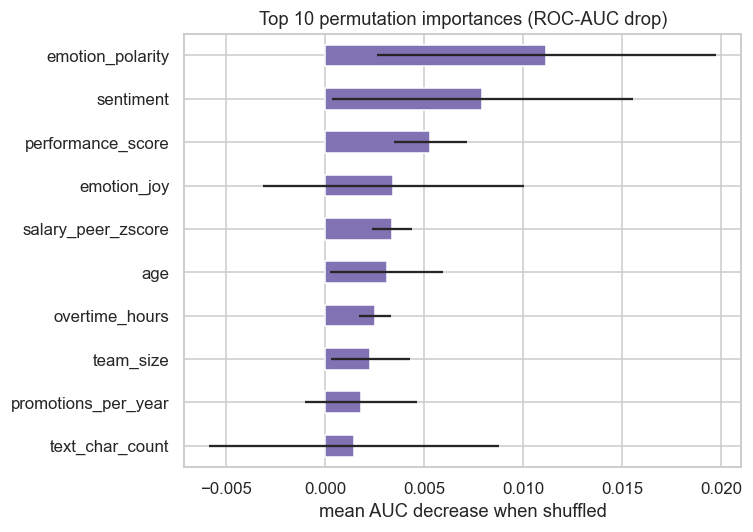

emotion_polarity     0.011
sentiment            0.008
performance_score    0.005
emotion_joy          0.003
salary_peer_zscore   0.003
age                  0.003
dtype: float64

In [11]:
from sklearn.inspection import permutation_importance
perm = permutation_importance(
    best, X_te, y_te, n_repeats=10, random_state=0, scoring='roc_auc')
perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
perm_imp.tail(10).plot.barh(
    ax=ax, color='#8172b3',
    xerr=perm.importances_std[perm_imp.tail(10).index.map(list(X.columns).index)])
ax.set_title('Top 10 permutation importances (ROC-AUC drop)')
ax.set_xlabel('mean AUC decrease when shuffled')
plt.tight_layout(); plt.show()
perm_imp.sort_values(ascending=False).head(6).round(4)

**The text signal survives a stricter test.** Permutation importance again puts **`emotion_polarity` and `sentiment` on top** (AUC drops of ~0.011 and ~0.008 when shuffled). It also re-ranks a couple of structured features upward relative to impurity importance — `performance_score` and `salary_peer_zscore` now appear in the top six — a useful reminder that the two methods disagree at the margins and that **peer-relative pay** carries more genuine signal than raw salary did in the EDA. The headline is unchanged: text features are the backbone of the model.

<a id="takeaways"></a>
## Takeaways

1. Models cluster around **0.70 CV AUC / 0.74 hold-out**; logistic regression is competitive with the trees.
2. **Precision@20 ≈ 0.70** and a **~1.7x top-decile lift** make the model useful for targeted outreach despite the modest global AUC.
3. The **F1-optimal threshold is ~0.35**, not 0.5 — tune the operating point to the cost of a missed departure.
4. **Calibration did not help** on this sample size — verify, don't assume.
5. **Text features dominate** both impurity and permutation importance, confirming the EDA thesis.